# <font color='blue'>SRP - Sentiment Rating Prediction</font>
## <font color='blue'>1- Fully Connected Neural Network</font>
## <font color='blue'>2- LSTM (Long Short-Term Memory)</font>
## <font color='blue'>3- BERT (Pre-Trained Transformer Model)</font>

In [1]:
!pip install -q -U watermark

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.0/107.0 kB 16.2 MB/s eta 0:00:00


In [2]:
# Use esta versão no ambiente local
#!pip install -q numpy==2.1.3

In [3]:
# Use esta versão no Colab
!pip install -q numpy==2.0.2

In [ ]:
#!pip install -q spacy

In [ ]:
#!pip install -q tensorflow

In [ ]:
#!pip install -q keras

In [ ]:
#!pip install -q tf-keras

In [ ]:
#!pip install -q keras-preprocessing

In [4]:
!pip install -q "transformers==4.44.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 91.7 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 124.2 MB/s eta 0:00:00


In [5]:
import transformers
print("Versão:", transformers.__version__)

# Verificar suporte TF de outra forma
try:
    import tensorflow as tf
    print("TF versão:", tf.__version__)
except:
    print("TensorFlow: NÃO instalado")

# Ver o que está disponível no transformers
print("\nTFAuto disponível:", hasattr(transformers, 'TFAutoModel'))
print("AutoConfig disponível:", hasattr(transformers, 'AutoConfig'))

Versão: 4.44.0
TF versão: 2.19.0

TFAuto disponível: True
AutoConfig disponível: True


In [6]:
%env TF_CPP_MIN_LOG_LEVEL=3

env: TF_CPP_MIN_LOG_LEVEL=3


In [7]:
# Imports — compatível com Keras 3.x / TensorFlow 2.19 / Colab
import math
import nltk
import spacy
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import transformers
from tokenizers import BertWordPieceTokenizer
from tqdm import tqdm
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from keras.utils import to_categorical, pad_sequences
from keras.models import Sequential, load_model
from keras.src.legacy.preprocessing.text import Tokenizer
from keras.metrics import Precision, Recall, AUC
from keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, Layer
from keras.callbacks import EarlyStopping, LearningRateScheduler, CallbackList, ReduceLROnPlateau
from keras.optimizers import Adam
from keras.regularizers import l1_l2
from keras.saving import register_keras_serializable
from transformers import TFDistilBertModel, DistilBertConfig
import warnings
warnings.filterwarnings('ignore')

In [8]:
%reload_ext watermark
%watermark -a "Silmara Basso" -d -t -v -p numpy,spacy,tensorflow,keras,transformers

Author: Silmara Basso

Date/Time: 2026-05-27 13:53:59

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

numpy       : 2.0.2
spacy       : 3.8.7
tensorflow  : 2.19.0
keras       : 3.10.0
transformers: 4.44.0



## Loading Text Data

In [11]:
import os

# Ver diretório atual
print("Diretório atual:", os.getcwd())

# Listar tudo em /content
print("\nConteúdo de /content:")
for item in os.listdir('/content'):
    print(" ", item)

# Ver se a pasta data existe
if os.path.exists('/content/data'):
    print("\nConteúdo de /content/data:")
    for item in os.listdir('/content/data'):
        print(" ", item)
else:
    print("\nPasta 'data' não existe em /content")

Diretório atual: /content

Conteúdo de /content:
  .config
  sample_data

Pasta 'data' não existe em /content


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [13]:
training_data_srp = pd.read_csv(
    '/content/drive/MyDrive/data/dt_training.txt',
    header=None,
    delimiter=';'
)

In [14]:
# Load the test data
test_srp_data = pd.read_csv(
    '/content/drive/MyDrive/data/dt_test.txt',
    header=None,
    delimiter=';'
)

In [15]:
# Adjust the column names
training_data_srp = training_data_srp.rename(columns = {0: 'message', 1: 'sentiment'})
test_srp_data = test_srp_data.rename(columns = {0: 'message', 1: 'sentiment'})

In [16]:
# Shape
training_data_srp.shape

(16000, 2)

In [17]:
# Shape
test_srp_data.shape

(2000, 2)

In [18]:
# Training sample
training_data_srp.head()

,message,sentiment
0,i am feeling completely overwhelmed i have two...,fear
1,i have the feeling she was amused and delighted,joy
2,i was able to help chai lifeline with your sup...,joy
3,i already feel like i fucked up though because...,anger
4,i still love my so and wish the best for him i...,sadness


The column **text** will be the input variable and **sentiment** the output variable.

In [19]:
# Feelings present in training data
training_data_srp['sentiment'].value_counts()

,count
sentiment,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


In [20]:
# Feelings present in test data
test_srp_data['sentiment'].value_counts()

,count
sentiment,
joy,695
sadness,581
anger,275
fear,224
love,159
surprise,66


## Preprocessing Text Data with SpaCy

https://spacy.io/

In [21]:
!python -m spacy download en_core_web_md -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.5/33.5 MB 21.1 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [22]:
# Load the dictionary
srp_nlp = spacy.load('en_core_web_md')

In [23]:
# Definition of the function 'srp_preprocess_text' that receives text as a parameter.
def srp_preprocess_text(text):

    # Process the text using the dictionary
    doc = srp_nlp(text)

    # Create a list of lemmas of the tokens, converted to lowercase and without whitespace,
    # excluding the words that are stopwords
    tokens = [token.lemma_.lower().strip() for token in doc if not token.is_stop]

    # Return the processed tokens as a single string, joining them with spaces
    return ' '.join(tokens)

In [24]:
# Apply the function to the training data
training_data_srp['processed_text'] = training_data_srp['message'].apply(srp_preprocess_text)

In [25]:
# Applies the function under test
test_srp_data['processed_text'] = test_srp_data['message'].apply(srp_preprocess_text)

In [26]:
# Sample data
training_data_srp.head()

,message,sentiment,processed_text
0,i am feeling completely overwhelmed i have two...,fear,feel completely overwhelmed strategy help feel...
1,i have the feeling she was amused and delighted,joy,feeling amuse delight
2,i was able to help chai lifeline with your sup...,joy,able help chai lifeline support encouragement ...
3,i already feel like i fucked up though because...,anger,feel like fuck not usually eat morning
4,i still love my so and wish the best for him i...,sadness,love wish good long tolerate effect bm life fa...


## Version 1 of the Model - Fully Connected Neural Network Architecture

### Step 1: Vectorization with TF-IDF

In [25]:
# Create the vectorizer
srp_tfidf = TfidfVectorizer(max_df = 0.95, min_df = 2, stop_words = 'english')

In [26]:
# Apply the vectorizer.
training_data_tfidf = srp_tfidf.fit_transform(training_data_srp['processed_text'])
test_data_tfidf = srp_tfidf.transform(test_srp_data['processed_text'])

In [27]:
training_data_tfidf.shape

(16000, 5593)

In [28]:
type(training_data_tfidf)

scipy.sparse._csr.csr_matrix

In [29]:
# Converts the input data (text) into an array.
X_training_array = training_data_tfidf.toarray()
X_test_array = test_data_tfidf.toarray()

### Step 2: Data Preparation

We now need to convert the target variable to a numeric representation. We will use Label Encoding.

In [30]:
# Create the label encoder.
srp_read_v1 = LabelEncoder()

In [31]:
# Fit and transform the target variable in training
y_training_read = srp_read_v1.fit_transform(training_data_srp['sentiment'])

In [32]:
# Perform a transformation on the target variable under test
y_test_read = srp_read_v1.transform(test_srp_data['sentiment'])

We will automatically address class imbalance

In [33]:
# Weight of classes
weights_classes = compute_class_weight('balanced', classes = np.unique(y_training_read), y = y_training_read)

In [34]:
type(weights_classes)

numpy.ndarray

In [35]:
# Division into Training and Test (validation) Data
X_training, X_validation, y_training, y_validation = train_test_split(X_training_array,
                                                                    y_training_read,
                                                                    test_size = 0.2,
                                                                    random_state = 42,
                                                                    stratify = y_training_read)

In [36]:
# Adjust the target variable as a categorical type
y_training_encoded = to_categorical(y_training)
y_test_encoded = to_categorical(y_test_read)
y_validation_encoded = to_categorical(y_validation)

In [37]:
# Shape
y_training_encoded.shape, y_test_encoded.shape, y_validation_encoded.shape

((12800, 6), (2000, 6), (3200, 6))

### Step 3: Building the Model

In [38]:

import sys
for name in sorted(sys.modules.keys()):
    if 'keras' in name.lower():
        print(name)

keras
keras._tf_keras
keras._tf_keras.keras
keras._tf_keras.keras.backend
keras._tf_keras.keras.layers
keras._tf_keras.keras.losses
keras._tf_keras.keras.metrics
keras._tf_keras.keras.preprocessing
keras._tf_keras.keras.preprocessing.image
keras._tf_keras.keras.preprocessing.sequence
keras._tf_keras.keras.preprocessing.text
keras.activations
keras.applications
keras.applications.convnext
keras.applications.densenet
keras.applications.efficientnet
keras.applications.efficientnet_v2
keras.applications.imagenet_utils
keras.applications.inception_resnet_v2
keras.applications.inception_v3
keras.applications.mobilenet
keras.applications.mobilenet_v2
keras.applications.mobilenet_v3
keras.applications.nasnet
keras.applications.resnet
keras.applications.resnet50
keras.applications.resnet_v2
keras.applications.vgg16
keras.applications.vgg19
keras.applications.xception
keras.backend
keras.callbacks
keras.config
keras.constraints
keras.datasets
keras.datasets.boston_housing
keras.datasets.californ

In [39]:
from keras.regularizers import L2

# Create the model
model_srp_v1 = Sequential()

# Add the first dense layer (fully-connected) to the model
model_srp_v1.add(Dense(4096,
                        activation='selu',
                        kernel_initializer='lecun_normal',
                        input_shape=(X_training.shape[1],),
                        kernel_regularizer=L2(0.01)))

# Add the second dense layer
model_srp_v1.add(Dense(2048,
                        activation='selu',
                        kernel_initializer='lecun_normal',
                        kernel_regularizer=L2(0.01)))

# Add the third dense layer
model_srp_v1.add(Dense(1024,
                        activation='selu',
                        kernel_initializer='lecun_normal',
                        kernel_regularizer=L2(0.1)))

# Add the fourth dense layer
model_srp_v1.add(Dense(64, activation='selu'))

# Add the output layer
model_srp_v1.add(Dense(6, activation='softmax'))

### Step 4: Model Compilation and Summary

In [40]:
# Assigns specific weights to the bias vector of the last layer of the model.
model_srp_v1.layers[-1].bias.assign(weights_classes)

<tf.Tensor: shape=(6,), dtype=float32, numpy=
array([1.2351397 , 1.3766993 , 0.49732688, 2.0449898 , 0.5715102 ,
       4.6620045 ], dtype=float32)>

In [41]:
# Compiles the model
# Defines the optimizer as 'Adam'.
# Adam is an optimization algorithm that can be used in place of the classic stochastic gradient descent procedure
# to update the network weights iteratively based on the training data.
# Defines the loss function as 'categorical_crossentropy'. It is suitable for multiclass classification problems
# where the labels are provided in a one-hot encoded format.
# Defines the model evaluation metric as 'accuracy'.
# Accuracy is a common metric for evaluating the performance of classification models.
model_srp_v1.compile(optimizer = 'Adam',
                     loss = tf.losses.categorical_crossentropy,
                     metrics = ['accuracy', Precision(), Recall(), AUC()])

In [42]:
model_srp_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4096)           │    22,913,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2048)           │     8,390,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,467,846 (127.67 MB)

 Trainable params: 33,467,846 (127.67 MB)

 Non-trainable params: 0 (0.00 B)

### Passo 5:  Callbacks & Early Stopping

In [43]:
# Function for scheduler parameters of the learning rate
def step_decay(epoch):
    initial_lrate = 0.001
    drop = 0.5
    epochs_drop = 10.0
    lrate = initial_lrate * math.pow(drop, math.floor((1 + epoch) / epochs_drop))
    return lrate

In [44]:
# Learning rate scheduler
lr_scheduler = LearningRateScheduler(step_decay)

In [45]:
# Early Stopping
early_stopping = EarlyStopping(monitor = 'val_loss', restore_best_weights = True, patience = 3)

### Step 6: Model Training

In [46]:
# Hyperparameters
epochs_num = 20
batch_size = 256

In [47]:
%%time
history_srp = model_srp_v1.fit(X_training,
                            y_training_encoded,
                            validation_data = (X_validation, y_validation_encoded),
                            epochs = epochs_num,
                            batch_size = batch_size,
                            callbacks = [early_stopping, lr_scheduler])

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.6616 - auc: 0.8986 - loss: 37.2204 - precision: 0.8025 - recall: 0.4781 - val_accuracy: 0.7788 - val_auc: 0.9633 - val_loss: 2.2680 - val_precision: 0.8574 - val_recall: 0.6875 - learning_rate: 0.0010
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.8077 - auc: 0.9685 - loss: 1.4910 - precision: 0.8772 - recall: 0.7124 - val_accuracy: 0.7891 - val_auc: 0.9609 - val_loss: 1.3843 - val_precision: 0.8718 - val_recall: 0.6909 - learning_rate: 0.0010
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 147s 2s/step - accuracy: 0.8209 - auc: 0.9720 - loss: 1.2454 - precision: 0.8776 - recall: 0.7494 - val_accuracy: 0.8091 - val_auc: 0.9678 - val_loss: 1.2644 - val_precision: 0.8718 - val_recall: 0.7309 - learning_rate: 0.0010
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 143s 2s/step - accuracy: 0.8517 - auc: 0.9808 - loss: 1.0775 - precision: 0.8966 - recall: 0.7937 - val_accuracy: 0.8244 - val_auc: 0.9714 - val_loss: 1.1601 - val_pre

### Step 7: Model Evaluation

In [48]:
# Extract training and validation loss
loss, val_loss = history_srp.history['loss'], history_srp.history['val_loss']

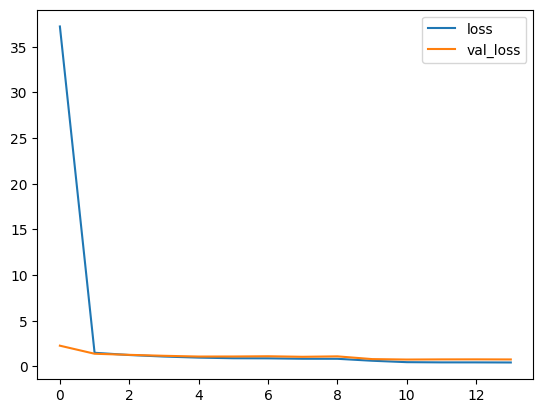

In [49]:
# Plot
plt.plot(loss, label = 'loss')
plt.plot(val_loss, label = 'val_loss')
plt.legend()
plt.show()

In [50]:
# Predictions based on test data
predictions_v1 = model_srp_v1.predict(X_test_array)

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step


In [51]:
# Extrai os labels
predictions_v1_labels = predictions_v1.argmax(axis = 1)

In [52]:
print(classification_report(y_test_read, predictions_v1_labels))

              precision    recall  f1-score   support

           0       0.88      0.82      0.85       275
           1       0.76      0.88      0.82       224
           2       0.88      0.90      0.89       695
           3       0.72      0.67      0.69       159
           4       0.89      0.88      0.88       581
           5       0.79      0.56      0.65        66

    accuracy                           0.85      2000
   macro avg       0.82      0.78      0.80      2000
weighted avg       0.85      0.85      0.85      2000



In [53]:
print(confusion_matrix(y_test_read, predictions_v1_labels))

[[225  14   8   3  25   0]
 [  9 197   4   0  11   3]
 [  5   6 625  35  18   6]
 [  2   2  37 106  11   1]
 [ 13  22  30   3 513   0]
 [  2  17   8   1   1  37]]


In [54]:
print(accuracy_score(y_test_read, predictions_v1_labels))

0.8515


In [55]:
# Save the template
model_srp_v1.save('model_srp_v1.keras')

### Step 8: Deploying Version 1 of the Model

In [56]:
# Load the model
model_loaded = load_model('model_srp_v1.keras')

In [57]:
# New sentence (feeling = fear)
phrase = "i even feel a little shaky"
df_new = pd.DataFrame({'Phrase': [phrase]})

In [58]:
#  Applies the function under test to the new sentence
df_new['Processed_Phrase'] = df_new['Phrase'].apply(srp_preprocess_text)

In [59]:
df_new

,Phrase,Processed_Phrase
0,i even feel a little shaky,feel little shaky


In [60]:
# Apply vectorization
df_new_tfidf = srp_tfidf.transform(df_new['Processed_Phrase'])

In [61]:
# Transform into an array
df_new_array = df_new_tfidf.toarray()

In [62]:
# Predictions
Predictions = model_loaded.predict(df_new_array)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


In [63]:
# Select the class with the highest probability
highest_probability_class = np.argmax(Predictions, axis = 1)

In [64]:
# Obtains the name of the class
class_name = srp_read_v1.inverse_transform(highest_probability_class)

In [65]:
# prediction
class_name

array(['fear'], dtype=object)

## Version 2 of the Model - LSTM (Long Short-Term Memory)


In [66]:
# Data processed with SpaCy
training_data_srp.head()

,message,sentiment,processed_text
0,i am feeling completely overwhelmed i have two...,fear,feel completely overwhelmed strategy help feel...
1,i have the feeling she was amused and delighted,joy,feeling amuse delight
2,i was able to help chai lifeline with your sup...,joy,able help chai lifeline support encouragement ...
3,i already feel like i fucked up though because...,anger,feel like fuck not usually eat morning
4,i still love my so and wish the best for him i...,sadness,love wish good long tolerate effect bm life fa...


In [67]:
# Creating the tokenizer
# from keras.preprocessing.text import Tokenizer
srp_tokenizer = Tokenizer()

In [68]:
# Adjusting the tokenizer with the processed texts
srp_tokenizer.fit_on_texts(training_data_srp['processed_text'])

In [69]:
# Extract the word indices
word_index = srp_tokenizer.word_index

In [70]:
len(word_index)

11835

In [71]:
# Print the first 10 items of the word index
for i, (key, value) in enumerate(word_index.items()):
    print(key, value)
    if i == 9:
        break

feel 1
like 2
m 3
not 4
feeling 5
know 6
time 7
t 8
want 9
think 10


In [72]:
# Conversion of training texts to token sequences
training_sequences = srp_tokenizer.texts_to_sequences(training_data_srp['processed_text'])

In [73]:
# Defining the maximum length of the sequences
max_length = 100

In [74]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import pad_sequences

In [75]:
# Padding of training sequences
training_sequences_padded = pad_sequences(training_sequences, maxlen = max_length, truncating = 'post')

In [76]:
# Converting test texts into token sequences
test_sequences = srp_tokenizer.texts_to_sequences(test_srp_data['processed_text'])

In [77]:
# Padding of test sequences
test_sequences_padded = pad_sequences(test_sequences, maxlen = max_length)

In [78]:
# Create the label encoder
srp_read_v2 = LabelEncoder()

In [79]:
# Fit and transform of the sentiment labels for training
y_training_read = srp_read_v2.fit_transform(training_data_srp['sentiment'])

In [80]:
# Transforming sentiment labels into tests.
y_test_read = srp_read_v2.transform(test_srp_data['sentiment'])

In [81]:
# Converting labels into categorical variables
y_training_encoded = to_categorical(y_training_read)
y_test_encoded = to_categorical(y_test_read)

In [82]:
# Defining the size of the vocabulary
vocab_size = len(srp_tokenizer.word_index) + 1

In [83]:
print(vocab_size)

11836


In [84]:
# Defining the dimension of the embedding
embedding_dim = max_length

In [85]:
# Construction of the LSTM model
model_srp_v2 = tf.keras.Sequential([Embedding(vocab_size, embedding_dim, input_length = max_length),
                                     Bidirectional(LSTM(64)),
                                     Dropout(0.4),
                                     Dense(32, activation = 'leaky_relu', kernel_regularizer = l1_l2(l1 = 0.01,
                                                                                                     l2 = 0.01)),
                                     Dropout(0.4),
                                     Dense(6, activation = 'softmax')])

In [86]:
# Model compilation
model_srp_v2.compile(loss = 'categorical_crossentropy',
                      optimizer = 'adam',
                      metrics = ['accuracy', Precision(), Recall(), AUC()])

In [87]:
# Displaying the model summary
print(model_srp_v2.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [88]:
# Defining the input data as an array
input_data = np.array(training_sequences_padded)

In [89]:
# Defining the output data as an array
output_data = np.array(y_training_encoded)

In [90]:
# Definition of hyperparameters
epochs_num = 35
validation_split_value = 0.2
patience = 5

In [91]:
# Early Stopping Configuration
early_stopping = tf.keras.callbacks.EarlyStopping(patience = patience)

> Model Training

In [92]:
%%time
history = model_srp_v2.fit(input_data,
                            output_data,
                            epochs = epochs_num,
                            verbose = 1,
                            validation_split = validation_split_value,
                            callbacks = [early_stopping])

Epoch 1/35
400/400 ━━━━━━━━━━━━━━━━━━━━ 59s 133ms/step - accuracy: 0.3206 - auc_1: 0.7015 - loss: 2.4309 - precision_1: 0.4348 - recall_1: 7.8125e-04 - val_accuracy: 0.3262 - val_auc_1: 0.7205 - val_loss: 1.6166 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/35
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 130ms/step - accuracy: 0.3430 - auc_1: 0.7796 - loss: 1.4961 - precision_1: 0.4926 - recall_1: 0.0572 - val_accuracy: 0.4097 - val_auc_1: 0.8414 - val_loss: 1.3322 - val_precision_1: 0.5048 - val_recall_1: 0.2150
Epoch 3/35
400/400 ━━━━━━━━━━━━━━━━━━━━ 50s 125ms/step - accuracy: 0.4310 - auc_1: 0.8600 - loss: 1.2471 - precision_1: 0.5111 - recall_1: 0.1803 - val_accuracy: 0.4322 - val_auc_1: 0.8605 - val_loss: 1.2293 - val_precision_1: 0.5000 - val_recall_1: 0.2809
Epoch 4/35
400/400 ━━━━━━━━━━━━━━━━━━━━ 83s 126ms/step - accuracy: 0.4538 - auc_1: 0.8746 - loss: 1.1473 - precision_1: 0.5274 - recall_1: 0.2298 - val_accuracy: 0.4331 - val_auc_1: 0.8661 - val_loss: 1.1884 - val_pre

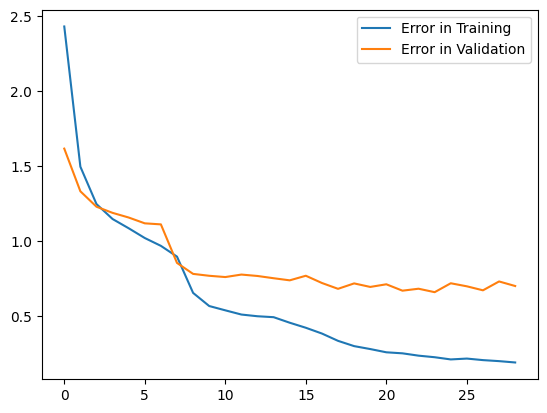

In [93]:
# Plot of error curves
loss, val_loss = history.history['loss'], history.history['val_loss']
plt.plot(loss, label = 'Error in Training')
plt.plot(val_loss, label = 'Error in Validation')
plt.legend()
plt.show()

In [94]:
# Predictions based on test data
predictions = model_srp_v2.predict(test_sequences_padded)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step


In [95]:
# Determination of predicted labels
predicted_labels = predictions.argmax(axis = 1)

In [96]:
# Display of the classification report
print(classification_report(y_test_read, predicted_labels))

              precision    recall  f1-score   support

           0       0.87      0.86      0.87       275
           1       0.83      0.88      0.85       224
           2       0.90      0.91      0.90       695
           3       0.70      0.70      0.70       159
           4       0.94      0.93      0.93       581
           5       0.77      0.67      0.72        66

    accuracy                           0.88      2000
   macro avg       0.84      0.82      0.83      2000
weighted avg       0.88      0.88      0.88      2000



In [97]:
# Display of the confusion matrix
print(confusion_matrix(y_test_read, predicted_labels))

[[236   8   9   8  13   1]
 [ 11 197   2   0   5   9]
 [  4   3 633  37  15   3]
 [  5   2  40 111   1   0]
 [ 14  10  17   1 539   0]
 [  0  17   4   1   0  44]]


In [98]:
# Display of the model's accuracy
print(accuracy_score(y_test_read, predicted_labels))

0.88


In [99]:
# Save the model
model_srp_v2.save('model_srp_v2.keras')

> Deploying the Model.

In [100]:
# Load the saved model
model_loaded = load_model('model_srp_v2.keras')

In [101]:
# New sentence (feeling = fear)
phrase = "i even feel a little shaky"

In [102]:
# Cria um dataframe com a frase
df_new = pd.DataFrame({'Phrase': [phrase]})

In [103]:
# Applies the processing function to the new sentence
df_new['Phrase_Processed'] = df_new['Phrase'].apply(srp_preprocess_text)

In [104]:
# Process the new data
new_sequences = srp_tokenizer.texts_to_sequences(df_new['Phrase_Processed'])
new_sequences_padded = pad_sequences(new_sequences, maxlen = max_length)

In [105]:
# Making predictions with the loaded model
previsoes = model_loaded.predict(new_sequences_padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step


In [106]:
# Select the class with the highest probability
highest_probability_class = np.argmax(predictions, axis = 1)

In [107]:
highest_probability_class

array([4, 0, 2, ..., 2, 2, 1])

In [108]:
# Get the class name
class_name = srp_read_v2.inverse_transform(highest_probability_class)

In [109]:
# Predicted class
class_name

array(['sadness', 'anger', 'joy', ..., 'joy', 'joy', 'fear'], dtype=object)

## Model Version 3 - Fine Tuning of Pre-Trained Transformer Model

I will use the data processed with SpaCy and then we will do the specific processing for the BERT model, just as we did with the model in version 1.

In [27]:
# Data processed with SpaCy
training_data_srp.head()

,message,sentiment,processed_text
0,i am feeling completely overwhelmed i have two...,fear,feel completely overwhelmed strategy help feel...
1,i have the feeling she was amused and delighted,joy,feeling amuse delight
2,i was able to help chai lifeline with your sup...,joy,able help chai lifeline support encouragement ...
3,i already feel like i fucked up though because...,anger,feel like fuck not usually eat morning
4,i still love my so and wish the best for him i...,sadness,love wish good long tolerate effect bm life fa...


In [28]:
# Function to encode texts using the tokenizer, with specified chunk size and maximum length for truncation and padding.
# Function to encode text into integer sequences for input into the BERT model.
def srp_encode(texts, tokenizer, chunk_size = 256, maxlen = 512):

    # Configures the tokenizer to truncate text to the specified maximum length
    tokenizer.enable_truncation(max_length = maxlen)

    # Configures the tokenizer to apply padding up to the specified maximum length
    tokenizer.enable_padding(length = maxlen)

    # List to store the input IDs generated by the tokenizer.
    input_ids = []

    # List to store the attention masks generated by the tokenizer.
    attention_masks = []

    # Iterates over the texts in blocks of the size specified by chunk_size
    for i in tqdm(range(0, len(texts), chunk_size)):

        # Selects a chunk of texts to process
        text_chunk = texts[i:i+chunk_size].tolist()

        # Encodes the chunk of text in batches using the tokenizer
        encs = tokenizer.encode_batch(text_chunk)

        # Adds the encoded input IDs to the input_ids list
        input_ids.extend([enc.ids for enc in encs])

        # Adds the generated attention masks to the attention_masks list
        attention_masks.extend([enc.attention_mask for enc in encs])

    # Returns the input IDs and attention masks as numpy arrays
    return np.array(input_ids), np.array(attention_masks)

https://huggingface.co/distilbert-base-multilingual-cased

In [29]:
# Loads the tokenizer from the pre-trained model
tokenizador_bert = transformers.DistilBertTokenizer.from_pretrained('distilbert-base-multilingual-cased')

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

In [30]:
# Saves the tokenizer to the current directory
tokenizador_bert.save_pretrained('.')

('./tokenizer_config.json',
 './special_tokens_map.json',
 './vocab.txt',
 './added_tokens.json')

In [31]:
# Loads a faster tokenizer using the vocabulary of the main tokenizer
# from tokenizers import BertWordPieceTokenizer
fast_tokenizer = BertWordPieceTokenizer('vocab.txt', lowercase = False)

In [32]:
# Visualizes the tokenizer
fast_tokenizer

Tokenizer(vocabulary_size=119547, model=BertWordPiece, unk_token=[UNK], sep_token=[SEP], cls_token=[CLS], pad_token=[PAD], mask_token=[MASK], clean_text=True, handle_chinese_chars=True, strip_accents=None, lowercase=False, wordpieces_prefix=##)

In [33]:
# Divide the data into training and validation sets using stratified sampling.
X_training, X_valid, Y_training, Y_valid = train_test_split(training_data_srp['processed_text'].values,
                                                        training_data_srp['sentiment'].values,
                                                        test_size = 0.2,
                                                        random_state = 42,
                                                        stratify = training_data_srp['sentiment'])

In [34]:
# Maximum length used in the text encoding process, which determines the truncation and padding of the input sequences.
max_length = 100

In [35]:
# Aplica a codificação (tokenização) em nossos dados
X_final_training, mask_training = srp_encode(X_training, fast_tokenizer, maxlen=max_length)
X_final_valid, mask_valid = srp_encode(X_valid, fast_tokenizer, maxlen=max_length)
X_final_test, mask_test = srp_encode(test_srp_data['processed_text'].to_numpy(), fast_tokenizer, maxlen=max_length)


100%|██████████| 8/8 [00:00<00:00, 99.29it/s]


In [36]:
X_final_training.shape

(12800, 100)

In [37]:
# Defines the encoder for the output data
srp_read_v3 = LabelEncoder()

In [38]:
# Aplica o codificador (fit_transform somente nos dados de treino)
y_training_read = srp_read_v3.fit_transform(Y_training)
y_valid_read = srp_read_v3.transform(Y_valid)
y_test_read = srp_read_v3.transform(test_srp_data['sentiment'])

In [39]:
# Converts the output variable to a categorical variable
y_training_encoded = to_categorical(y_training_read)
y_valid_encoded = to_categorical(y_valid_read)
y_test_encoded = to_categorical(y_test_read)

In [40]:
# batch size
BATCH_SIZE = 16

In [41]:
# Creates a TensorFlow dataset for training, which includes the input data (X_final_training and mask_training) and the corresponding labels (y_training_encoded). The dataset is configured to repeat indefinitely, shuffle the data with a buffer size of 2048, and batch the data into groups of size specified by BATCH_SIZE.
dataset_training = (
    tf.data.Dataset
    .from_tensor_slices(((X_final_training, mask_training), y_training_encoded))
    .repeat()
    .shuffle(2048)
    .batch(BATCH_SIZE)
)

In [42]:
# Creates a TensorFlow dataset for validation, which includes the input data (X_final_valid and mask_valid) and the corresponding labels (y_valid_encoded). The dataset is configured to batch the data into groups of size specified by BATCH_SIZE and cache the data for improved performance during training.
dataset_valid = (
    tf.data.Dataset
    .from_tensor_slices(((X_final_valid, mask_valid), y_valid_encoded))
    .batch(BATCH_SIZE)
    .cache()
)

In [43]:
# Prepare the test dataset in the format expected by TensorFlow
dataset_test = (
    tf.data.Dataset
    .from_tensor_slices(((X_final_test, mask_test), y_test_encoded))
    .batch(BATCH_SIZE)
)

In [50]:
from keras import Input, Model

# Function to create the model using a custom Transformer layer
def srp_create_model(transformer, max_len=512):

    # Input layer for word IDs
    input_word_ids = Input(
        shape=(max_len,), dtype='int32', name="input_word_ids"
    )

    # Input layer for attention mask
    attention_mask = Input(
        shape=(max_len,), dtype='int32', name="attention_mask"
    )

    # Custom layer for the Transformer
    sequence_output = TransformerLayer(transformer)(
        [input_word_ids, attention_mask]
    )

    # Selecting the CLS token (first token)
    cls_token = sequence_output[:, 0, :]

    # Dense layer with softmax for classification
    out = Dense(6, activation="softmax")(cls_token)

    # Keras model
    model = Model(
        inputs=[input_word_ids, attention_mask], outputs=out
    )

    # Compiling the model
    model.compile(
        optimizer=Adam(learning_rate=1e-5),
        loss="categorical_crossentropy",
        metrics=["accuracy", Precision(), Recall(), AUC()],
    )

    return model

> Loading the Pre-Trained Model:

https://huggingface.co/distilbert-base-multilingual-cased

In [45]:
# Register the TransformerLayer class as serializable in Keras
@register_keras_serializable(package = "Custom", name = "TransformerLayer")
class TransformerLayer(Layer):

    # Initializes the TransformerLayer class with the Transformer model and other settings
    def __init__(self, transformer, **kwargs):

        # Initializes the base Layer class
        super().__init__(**kwargs)

        #  Stores the Transformer model in the class
        self.transformer = transformer

    # Defines the call operation of the layer, executed at the time of training or inference
    def call(self, inputs):

        # Unpacks the inputs (input_ids and attention_mask)
        input_ids, attention_mask = inputs

        # Executes the Transformer model
        outputs = self.transformer(input_ids=input_ids, attention_mask=attention_mask)

        # Returns the last hidden output of the Transformer model
        return outputs.last_hidden_state

    # Defines how the layer will be serialized
    def get_config(self):

        # Obtains the configuration of the base class
        config = super().get_config()

        # Adds the complete configuration of the Transformer model
        config.update({
            "transformer_config": self.transformer.config.to_dict()  # Saves the configuration of the Transformer
        })
        return config  # Returns the complete layer configuration

    # Method to recreate the layer from a saved configuration
    @classmethod
    def from_config(cls, config):

        # Reconstructs the Transformer configuration from the saved configuration
        transformer_config = DistilBertConfig.from_dict(config["transformer_config"])

        # Loads the pre-trained Transformer model with the reconstructed configuration
        transformer = TFDistilBertModel.from_pretrained(
            "distilbert-base-multilingual-cased",
            config=transformer_config
        )

        # Returns a new instance of the TransformerLayer
        return cls(transformer=transformer)

In [46]:
# Loading the pre-trained model
transformer_layer = TFDistilBertModel.from_pretrained(
    "distilbert-base-multilingual-cased"
)

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [51]:
#   Creating the model using the custom Transformer layer and specifying the maximum sequence length for truncation and padding of the input data.
model_srp_v3 = srp_create_model(transformer_layer, max_len = max_length)


In [131]:
# Displaying the model summary
model_srp_v3.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_word_ids      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer   │ (None, 100, 768)  │          0 │ input_word_ids[0… │
│ (TransformerLayer)  │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 768)       │          0 │ transformer_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 6)         │      4,614 │ get_item[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,614 (18.02 KB)

 Trainable params: 4,614 (18.02 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Setting the first three layers of the model to non-trainable
model_srp_v3.layers[0].trainable = False
model_srp_v3.layers[1].trainable = False
model_srp_v3.layers[2].trainable = False

In [53]:
#   summary
model_srp_v3.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_word_ids      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 100)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_layer_1 │ (None, 100, 768)  │          0 │ input_word_ids[0… │
│ (TransformerLayer)  │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 768)       │          0 │ transformer_laye… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 6)         │      4,614 │ get_item[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,614 (18.02 KB)

 Trainable params: 4,614 (18.02 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
#  Defining the number of steps per epoch based on the size of the training data and the batch size, and setting the number of epochs for training.
n_steps = X_final_training.shape[0] // BATCH_SIZE
epochs_num = 3

>  Model Training

In [55]:
%%time
history = model_srp_v3.fit(dataset_training,
                            steps_per_epoch = n_steps,
                            validation_data = dataset_valid,
                            epochs = epochs_num)

Epoch 1/3
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 76ms/step - accuracy: 0.2588 - auc_1: 0.5518 - loss: 1.8113 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00 - val_accuracy: 0.3038 - val_auc_1: 0.7037 - val_loss: 1.6151 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 2/3
800/800 ━━━━━━━━━━━━━━━━━━━━ 56s 70ms/step - accuracy: 0.3118 - auc_1: 0.7078 - loss: 1.6006 - precision_1: 0.0549 - recall_1: 4.4057e-06 - val_accuracy: 0.3313 - val_auc_1: 0.7164 - val_loss: 1.5813 - val_precision_1: 0.0000e+00 - val_recall_1: 0.0000e+00
Epoch 3/3
800/800 ━━━━━━━━━━━━━━━━━━━━ 55s 69ms/step - accuracy: 0.3326 - auc_1: 0.7143 - loss: 1.5815 - precision_1: 0.4737 - recall_1: 4.3858e-04 - val_accuracy: 0.3444 - val_auc_1: 0.7224 - val_loss: 1.5708 - val_precision_1: 0.5000 - val_recall_1: 9.3750e-04
CPU times: user 46 s, sys: 8.09 s, total: 54 s
Wall time: 3min 2s


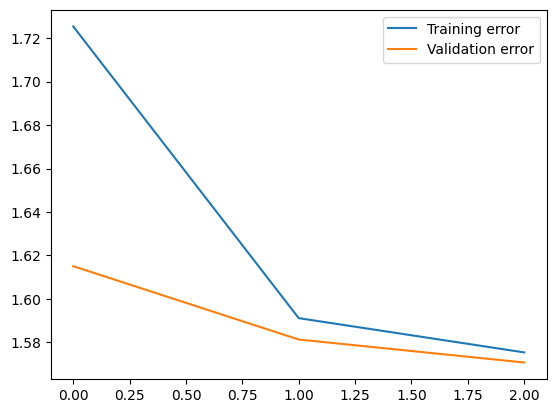

In [56]:
# Plot of error curves
loss, val_loss = history.history['loss'], history.history['val_loss']
plt.plot(loss, label = 'Training error')
plt.plot(val_loss, label = 'Validation error')
plt.legend()
plt.show()

In [57]:
# Applying the encoding function to the test data to prepare it for prediction with the trained model.
X_final_test, mask_test = srp_encode(
    test_srp_data['processed_text'].to_numpy(),
    fast_tokenizer,
    maxlen = max_length
)

# Perform the forecast using both tensors
predictions = model_srp_v3.predict((X_final_test, mask_test))

100%|██████████| 8/8 [00:00<00:00, 91.23it/s]


63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step


In [58]:
# Labels
labels_predictions = predictions.argmax(axis = 1)

In [59]:
print(classification_report(y_test_read, labels_predictions))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       275
           1       0.00      0.00      0.00       224
           2       0.36      0.70      0.47       695
           3       0.00      0.00      0.00       159
           4       0.30      0.33      0.31       581
           5       0.00      0.00      0.00        66

    accuracy                           0.34      2000
   macro avg       0.11      0.17      0.13      2000
weighted avg       0.21      0.34      0.25      2000



In [60]:
print(confusion_matrix(y_test_read, labels_predictions))

[[  0   0 177   0  98   0]
 [  0   0 158   0  66   0]
 [  0   1 486   0 208   0]
 [  0   0 104   0  55   0]
 [  0   0 391   0 190   0]
 [  0   0  46   0  20   0]]


In [61]:
print(accuracy_score(y_test_read, labels_predictions))

0.338


In [62]:
# Save the model
model_srp_v3.save("model_srp_v3.keras")

> Deploying the Model

In [63]:
# Load the model

# Imports
from transformers import TFDistilBertModel
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import custom_object_scope

model_reloaded = load_model(
    "model_srp_v3.keras",
    custom_objects = {"TransformerLayer": TransformerLayer}
)

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertModel: ['vocab_projector.bias', 'vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFDistilBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFDistilBertModel for predictions without further training.


In [66]:
# New sentence (feeling = fear)
phrase = "i even feel a little shaky"

In [67]:
# Creates a dataframe with the sentence
df_new = pd.DataFrame({'Phrase': [phrase]})

In [68]:
# Applies the processing function to the new sentence
df_new['Phrase_Processed'] = df_new['Phrase'].apply(srp_preprocess_text)

In [69]:
new_data = srp_encode(df_new['Phrase_Processed'], fast_tokenizer, maxlen = max_length)

100%|██████████| 1/1 [00:00<00:00, 2465.79it/s]


In [70]:
# Making predictions with the loaded model
predictions = model_srp_v3.predict(new_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [71]:
# Select the class with the highest probability
highest_probability_class = np.argmax(predictions, axis = 1)

In [72]:
highest_probability_class

array([2])

In [73]:
# Get the class name
class_name = srp_read_v3.inverse_transform(highest_probability_class)

In [74]:
# Get the class name
class_name

array(['joy'], dtype=object)

In [75]:
# To avoid parallelism issues with tokenizers, we set the environment variable TOKENIZERS_PARALLELISM to false.
%env TOKENIZERS_PARALLELISM=false

env: TOKENIZERS_PARALLELISM=false


In [79]:
%watermark -a "Silmara Basso"

Author: Silmara Basso



In [77]:
%watermark -v -m

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.122+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 2
Architecture: 64bit



In [78]:
%watermark --iversions

google      : 2.0.3
keras       : 3.10.0
matplotlib  : 3.10.0
nltk        : 3.9.1
numpy       : 2.0.2
pandas      : 2.2.2
sklearn     : 1.6.1
spacy       : 3.8.7
tensorflow  : 2.19.0
tokenizers  : 0.19.1
tqdm        : 4.67.1
transformers: 4.44.0



# Fim